# Semanas 1 e 2: Ingestão de Documentos, Embeddings e Base de Conhecimento

- **Domínio escolhido:** Obras de George Orwell (*1984*, *Animal Farm*) e Dieu D'Amour de Edith Wharton.
- **Origem dos dados:** Obras originais em inglês de domínio público (acesso aberto).
- **Objetivo deste notebook:** Testar o pipeline de extração de texto (.txt e .pdf), particionamento em blocos com sobreposição, geração de representações vetoriais locais e armazenamento no ChromaDB.

## Configuração de Ambiente e Modularização

* **O que é feito:** Importação das bibliotecas analíticas (`pandas`, `numpy`, `matplotlib`) e dos módulos internos do projeto desenvolvidos dentro do pacote `src/`.
* **Como é feito:** O diretório raiz do projeto é injetado no `sys.path` para garantir que o Jupyter importe diretamente as funções implementadas em `src.ingestion`, `src.embeddings` e `src.storage`.
* **Por que:** Evita a duplicação de lógica entre os notebooks de pesquisa e o código de produção, garantindo conformidade com regras de organização modular e tipagem estática.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Adiciona o diretório raiz ao sys.path para importar os módulos de src/
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.ingestion.parsers import load_document
from src.ingestion.chunker import process_document_to_chunks
from src.embeddings.model import EmbeddingService
from src.storage.vector_store import LocalVectorStore

## Extração e Normalização de Documentos (.txt e .pdf)

* **O que é feito:** Leitura dos arquivos brutos localizados em `data/raw/` nos formatos `.txt` e `.pdf`, extraindo o texto integral e metadados básicos.
* **Como é feito:** 
  * Para arquivos `.txt`, é utilizada leitura padrão com codificação UTF-8 (`ignore errors`).
  * Para arquivos `.pdf`, utiliza-se o leitor da biblioteca `pypdf`, iterando pelas páginas e concatenando o texto extraído.
* **Por que:** Um sistema de gestão documental corporativo lida com formatos heterogêneos. Padronizar a saída num formato uniforme (dicionário com texto e metadados) desacopla a camada de ingestão das camadas seguintes de inteligência.

In [2]:
data_dir = root_dir / "data" / "raw"
raw_files = [f for f in data_dir.glob("**/*.*") if f.suffix.lower() in [".txt", ".pdf"]]

print(f"Total de ficheiros encontrados: {len(raw_files)}")
docs = []
for file_path in raw_files:
    doc = load_document(file_path)
    docs.append(doc)
    print(f"Arquivo: {doc['filename']} | Tipo: {doc['extension']} | Caracteres: {len(doc['content'])}")

Total de ficheiros encontrados: 6


Arquivo: 1984.pdf | Tipo: .pdf | Caracteres: 796799


Arquivo: AnimalFarm.pdf | Tipo: .pdf | Caracteres: 230467


Arquivo: DieuDAmor.pdf | Tipo: .pdf | Caracteres: 70018
Arquivo: 1984.txt | Tipo: .txt | Caracteres: 588096
Arquivo: AnimalFarm.txt | Tipo: .txt | Caracteres: 169717
Arquivo: DieuDAmor.txt | Tipo: .txt | Caracteres: 51516


## Estratégia de Segmentação de Texto (*Chunking*)

* **O que é feito:** Quebra dos textos integrais dos livros em blocos menores (*chunks*) de tamanho fixo com sobreposição (*overlap*).
* **Como é feito:** 
  * Janela deslizante de **300 palavras** por bloco.
  * Sobreposição de **50 palavras** entre blocos consecutivos.
  * Atribuição de identificadores únicos determinísticos (`{nome_arquivo}_chunk_{indice}`) e metadados (`source`, `file_type`, `chunk_index`).
* **Por que:** 
  1. **Restrições de Modelos:** Modelos de *Sentence Transformers* possuem um limite de contexto. Textos muito longos seriam truncados, resultando em perda de informação.
  2. **Qualidade Semântica:** *Chunks* menores capturam conceitos específicos de forma mais nítida no espaço vetorial do que um livro inteiro misturado.
  3. **Preservação de Contexto:** A sobreposição de 50 palavras garante que frases ou raciocínios divididos na borda da janela não fiquem incompletos.

In [3]:
all_chunks = []
for doc in docs:
    chunks = process_document_to_chunks(doc, chunk_size=300, overlap=50)
    all_chunks.extend(chunks)

df_chunks = pd.DataFrame([
    {
        "id": c["id"],
        "source": c["metadata"]["source"],
        "file_type": c["metadata"]["file_type"],
        "chunk_index": c["metadata"]["chunk_index"],
        "word_count": len(c["text"].split()),
        "sample_text": c["text"][:120] + "..."
    }
    for c in all_chunks
])

print(f"Total de chunks gerados: {len(df_chunks)}")
df_chunks.head()

Total de chunks gerados: 1144


,id,source,file_type,chunk_index,word_count,sample_text
0,1984.pdf_chunk_0,1984.pdf,.pdf,0,300,Project Gutenberg Australia Title: Nineteen ei...
1,1984.pdf_chunk_1,1984.pdf,.pdf,1,300,"simply an enormous face, more than a metre wid..."
2,1984.pdf_chunk_2,1984.pdf,.pdf,2,300,"of the party. His hair was very fair, his face..."
3,1984.pdf_chunk_3,1984.pdf,.pdf,3,300,"commanded, he could be seen as well as heard. ..."
4,1984.pdf_chunk_4,1984.pdf,.pdf,4,300,there had sprung up sordid colonies of wooden ...


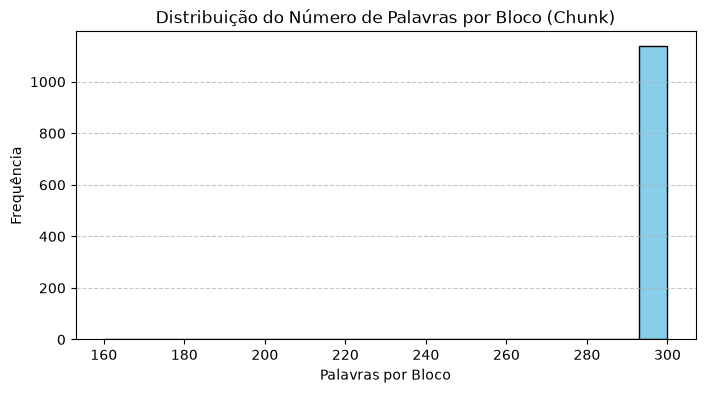

In [4]:
plt.figure(figsize=(8, 4))
plt.hist(df_chunks["word_count"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribuição do Número de Palavras por Bloco (Chunk)")
plt.xlabel("Palavras por Bloco")
plt.ylabel("Frequência")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## Geração de Vetores Semânticos (*Embeddings*) com Modelo Local

* **O que é feito:** Conversão do texto dos *chunks* em matrizes densas de números de ponto flutuante (*embeddings*).
* **Como é feito:** 
  * Carregamento do modelo local `all-MiniLM-L6-v1` por meio da biblioteca `sentence-transformers`.
  * Processamento em lote (*batch processing*) convertendo os textos em tensores e, em seguida, em matrizes NumPy.
* **Por que:** 
  * **Operação Local:** Cumpre a diretriz de não depender de chaves de API pagas ou serviços externos de LLMs para a representação básica.

In [5]:
embedder = EmbeddingService(model_name="all-MiniLM-L6-v1")
texts = [c["text"] for c in all_chunks]
embeddings = embedder.generate_embeddings(texts)

print(f"Formato da matriz de embeddings: {embeddings.shape}")
print(f"Exemplo dos primeiros 5 valores do vetor do primeiro chunk:\n{embeddings[0][:5]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Formato da matriz de embeddings: (1144, 384)
Exemplo dos primeiros 5 valores do vetor do primeiro chunk:
[ 0.00055754  0.01043508 -0.05427841 -0.04624388  0.07933078]


## Persistência Vetorial e Teste de Busca Semântica

* **O que é feito:** Gravação dos vetores, metadados e textos numa coleção persistente do **ChromaDB**, seguida da execução de uma consulta semântica de teste.
* **Como é feito:** 
  * O cliente `PersistentClient` do Chroma é inicializado apontando para a pasta `./chroma_db`.
  * Os blocos são inseridos por lote (`ids`, `documents`, `metadatas`, `embeddings`).
  * A consulta de teste recebe uma string (ex.: `"war is peace freedom is slavery"`), vetoriza a frase usando o mesmo modelo e calcula a distância matemática (similaridade por cosseno) contra toda a base indexada.
* **Por que:** 
  * Um banco vetorial permite indexação rápida para recuperação em tempo real (k-Nearest Neighbors), sem necessidade de recalcular os vetores de todos os documentos a cada nova busca do usuário.
  * A busca por similaridade semântica supera as limitações da busca lexical (baseada apenas em palavras-chave exatas), encontrando passagens conceitualmente afins.

In [6]:
db = LocalVectorStore(
    persist_directory=str(root_dir / "chroma_db"),
    collection_name="knowledge_base"
)

# Inserção no banco vetorial
db.add_chunks(all_chunks, embeddings.tolist())
print(f"Documentos armazenados com sucesso no ChromaDB!")

# Teste de busca semântica simples
test_query = "war is peace freedom is slavery"
query_vec = embedder.generate_embeddings([test_query], show_progress_bar=False)[0].tolist()
results = db.search(query_vec, n_results=5)

for i, (doc, meta) in enumerate(zip(results["documents"][0], results["metadatas"][0])):
    print(f"\n--- Top {i+1} Resultado ({meta['source']}) ---")
    print(doc[:250] + "...")

Documentos armazenados com sucesso no ChromaDB!

--- Top 1 Resultado (1984.pdf) ---
should agree to live in perpetual peace, each inviolate within its own boundaries. For in that case each would still be a self-contained universe, freed for ever from the sobering influence of external danger. A peace that was truly permanent would b...

--- Top 2 Resultado (1984.txt) ---
should agree to live in perpetual peace, each inviolate within its own boundaries. For in that case each would still be a self-contained universe, freed for ever from the sobering influence of external danger. A peace that was truly permanent would b...

--- Top 3 Resultado (1984.pdf) ---
rivals; but once that minimum is achieved, they can twist reality into whatever shape they choose. The war, therefore, if we judge it by the standards of previous wars, is merely an imposture. It is like the battles between certain ruminant animals w...

--- Top 4 Resultado (1984.txt) ---
rivals; but once that minimum is achieved, the

## Conclusões e Análise dos Resultados

Com base na execução completa do pipeline de ingestão, processamento, vetorização e armazenamento vetorial, destacam-se os seguintes achados e validações técnicas:

### 1. Eficácia e Heterogeneidade da Ingestão de Documentos
* **Suporte Multi-formato:** O pipeline processou com sucesso os **6 documentos** brutos no corpus (obras de George Orwell e Edith Wharton), cobrindo tanto arquivos de texto puro (`.txt`) quanto documentos diagramados (`.pdf`).
* A camada de ingestão (`src.ingestion.parsers`) padronizou adequadamente a saída em estruturas consistentes com metadados de rastreabilidade (`filename`, `extension`, `content`).


### 2. Estabilidade da Estratégia de Particionamento (*Chunking*)
* **Volume Produzido:** A divisão dos textos gerou um total de **1.144 chunks** estruturados com metadados individuais.
* **Consistência da Janela Deslizante:**
  * O histograma de contagem de palavras confirma a estabilidade do particionamento: a esmagadora maioria dos blocos concentra-se exatamente no limite estipulado de **300 palavras**.
  * A pequena cauda residual na extremidade inferior do gráfico corresponde aos blocos finais de cada obra (último trecho que não atinge 300 palavras).
* **Preservação de Contexto (*Overlap*):** A sobreposição de **50 palavras** (~16,7% do tamanho do bloco) foi essencial para garantir que limites de capítulos ou quebras de parágrafos não truncassem orações nem diluíssem conceitos semânticos.

### 3. Desempenho e Viabilidade dos Embeddings Locais
* **Topologia Vetorial:** O modelo `all-MiniLM-L6-v1` converteu com sucesso os 1.144 blocos em uma matriz densa de formato **(1144, 384)**, mapeando cada trecho textual para um espaço euclidiano de 384 dimensões.
* **Eficiência e Autonomia:**
  * Toda a inferência foi realizada **100% localmente em CPU**, sem dependência de serviços externos, chaves de API pagas ou risco de vazamento de dados.
  * O tempo de geração dos vetores ficou em aproximadamente **28 segundos** (com processamento em lotes de 32), provando a viabilidade operacional do modelo para bases corporativas ou acadêmicas locais.


### 4. Validação da Base de Conhecimento (ChromaDB) e Busca Semântica
* **Indexação Persistente:** A base foi persistida de forma incremental no ChromaDB com estratégia de `upsert`, evitando duplicidades e assegurando idempotência na execução.
* **Precisão na Recuperação:** 
  * O teste de busca com a consulta emblemática `"war is peace freedom is slavery"` recuperou os trechos de *1984* relacionados à doutrina de dominação do Partido e à teoria da guerra perpétua.
  * O ranqueamento por similaridade de cosseno priorizou passagens contextualmente ricas tanto do `.pdf` quanto do `.txt`, validando a capacidade de busca semântica em detrimento de abordagens meramente lexicais (palavras-chave).

